In [ ]:
# Load packages
suppressPackageStartupMessages({
    library(ggplot2)
    library(biomaRt)
    library(BiocParallel)
    library(Matrix)
    library(matrixStats)
    library(scater)
    library(reshape2)
    library(knitr)
    library(scran)
    library(SingleCellExperiment)
    library(Seurat)
    library(data.table)
    library(dplyr)
    library(gridExtra)
    library(viridis)
    
    library(edgeR)
    library(ggrastr)
    library(ggrepel)
})
    ncores = 4
    mcparam = MulticoreParam(workers = ncores)
    register(mcparam)
    BPPARAM = SerialParam()

options(repr.plot.width=15, repr.plot.height=8)

In [9]:
in_folder = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/'

In [2]:
load_data = function(){
        in_folder = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/WT_injection/'
        counts = readRDS(paste0(in_folder, "raw_counts.rds"))
        genes = read.table(paste0(in_folder, "genes.tsv"), stringsAsFactors = F)
        meta = read.csv(paste0(in_folder, "meta.tab"), stringsAsFactors = F, sep='\t')
        sfs = read.table(paste0(in_folder, "sizefactors.tab"), stringsAsFactors = F)[,1]

        counts = counts[,meta$doublet==FALSE & meta$stripped==FALSE]
        sfs = sfs[meta$doublet==FALSE & meta$stripped==FALSE]
        meta = meta[meta$doublet==FALSE & meta$stripped==FALSE,]

        meta = read.csv(paste0(in_folder, "meta_complete.csv"), stringsAsFactors = F)

        # Correct tdTom annotation
        exp_design = data.frame('sample' = c(1,2,3,4,5,6,7,8,9,10), 
                       'tdTom' = c('positive', 'negative',
                                'positive', 'negative',
                                'positive', 'negative',
                                'negative', 'positive',
                                'negative', 'positive'))
        meta = merge(meta, exp_design, by='sample')

        rownames(counts) = genes[,1] #ensembl
        colnames(counts) = meta$cell

        sce = SingleCellExperiment(assays = list("counts" = counts))

        sizeFactors(sce) = sfs
        sce = scater::logNormCounts(sce)

        genenames = fread("/rds/project/rds-SDzz0CATGms/users/bt392/gene_names.csv") %>% 
            setnames(c('ensembl_gene_id','external_gene_name'), c('gene', 'gene_name'))
        genenames = genenames[genenames$gene %in% rownames(sce)]
        genenames = merge(genenames, as.data.frame(rownames(sce)), by.x='gene', by.y='rownames(sce)', all.y=TRUE)
        genenames$gene_name[genenames$gene_name==''] = NA
        genenames[is.na(genenames$gene_name),] = genenames$gene[is.na(genenames$gene_name)]
        genenames = genenames[order(match(genenames$gene, rownames(sce)))]
        rownames(sce) = genenames$gene_name

    assign("genes", genes, envir = .GlobalEnv)
    assign("meta", meta, envir = .GlobalEnv)
    assign("sce", sce, envir = .GlobalEnv)
    }

In [3]:
opts=list()
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

gg_volcano_plot <- function(to.plot, top_genes=10, xlim=NULL, ylim=NULL, label_groups = NULL) {
  
  negative_hits <- to.plot[sig==TRUE & logFC<0,gene]
  positive_hits <- to.plot[sig==TRUE & logFC>0,gene]
  all <- nrow(to.plot)
  
  # if (is.null(xlim))
  #   xlim <- max(abs(to.plot$logFC), na.rm=T)
  # if (is.null(ylim))
  #   ylim <- max(-log10(to.plot$padj_fdr+1e-100), na.rm=T)
  
  to.plot <- to.plot[!is.na(logFC) & !is.na(padj_fdr)]
  
  p <- ggplot(to.plot, aes(x=logFC, y=-log10(padj_fdr+1e-100))) +
    labs(x="Log fold change", y=expression(paste("-log"[10],"(q.value)"))) +
    ggrastr::geom_point_rast(aes(color=sig, size=sig)) +
    # geom_hline(yintercept = -log10(opts$threshold_fdr), color="blue") +
    geom_segment(aes(x=0, xend=0, y=0, yend=105), color="orange", size=0.5) +
    scale_color_manual(values=c("black","red")) +
    scale_size_manual(values=c(0.5,1)) +
    scale_x_continuous(limits=c(-6,6)) +
    scale_y_continuous(limits=c(0,115)) +
    annotate("text", x=0, y=115, size=4, label=sprintf("(%d)", all)) +
    annotate("text", x=-5, y=115, size=4, label=sprintf("%d (-)",length(negative_hits))) +
    annotate("text", x=5, y=115, size=4, label=sprintf("%d (+)",length(positive_hits))) +
    ggrepel::geom_text_repel(data=head(to.plot[sig==T],n=top_genes), aes(x=logFC, y=-log10(padj_fdr+1e-100), label=gene), max.overlaps=Inf, size=4) +
    theme_classic() +
    theme(
      axis.text = element_text(size=rel(0.75), color='black'),
      axis.title = element_text(size=rel(1.0), color='black'),
      legend.position="none"
    )
  
  
  if (length(label_groups)>0) {
    p <- p +
      annotate("text", x=-4, y=0, size=4, label=sprintf("Up in %s",label_groups[2])) +
      annotate("text", x=4, y=0, size=4, label=sprintf("Up in %s",label_groups[1]))
  }
  
  return(p)
}

# Function to differential expression
# - sce: SingleCellExperiment object with the column "group" in the colData
# - groups: the names of the two groups
# - min_detection_rate_per_group: minimum detection rate per group
doDiffExpr <- function(sce, groups, min_detection_rate_per_group = 0.50) {
    
  # Sanity checks
  if (!is(sce, "SingleCellExperiment")) stop("'sce' has to be an instance of SingleCellExperiment")
  stopifnot(length(groups)==2)

  # Filter genes by detection rate per group
  cdr_A <- rowMeans(logcounts(sce[,sce$group==groups[1]])>0) >= min_detection_rate_per_group
  cdr_B <- rowMeans(logcounts(sce[,sce$group==groups[2]])>0) >= min_detection_rate_per_group
  out <- .edgeR(sce[cdr_B | cdr_A,]) %>% .[,log_padj_fdr:= -log10(padj_fdr)]
  
  return(out)
}


.edgeR <- function(sce) {
  
  # Convert SCE to DGEList
  
  sce_edger <- scran::convertTo(sce, type="edgeR")
 # sce_edger$samples$norm.factors = sce_edger$samples$sizeFactor
    
  # Define design matrix (with intercept)
  cdr <- colMeans(logcounts(sce)>0)
  design <- model.matrix(~cdr+sce$group)
  
  # Estimate dispersions
  sce_edger  <- estimateDisp(sce_edger,design)
  
  # Fit GLM
  fit <- glmQLFit(sce_edger,design)
  
  # Likelihood ratio test
  lrt <- glmQLFTest(fit)
  
  # Construct output data.frame
  out <- topTags(lrt, n=nrow(lrt))$table %>% as.data.table(keep.rownames=T) %>%
    setnames(c("gene","logFC","logCPM","LR","p.value","padj_fdr")) %>%
    .[,c("logCPM","LR"):=NULL]
  
  return(out)
}

In [86]:
load_data()

In [87]:
sce = sce[, meta$stage=='E8.5']
meta = meta[meta$stage=='E8.5',]

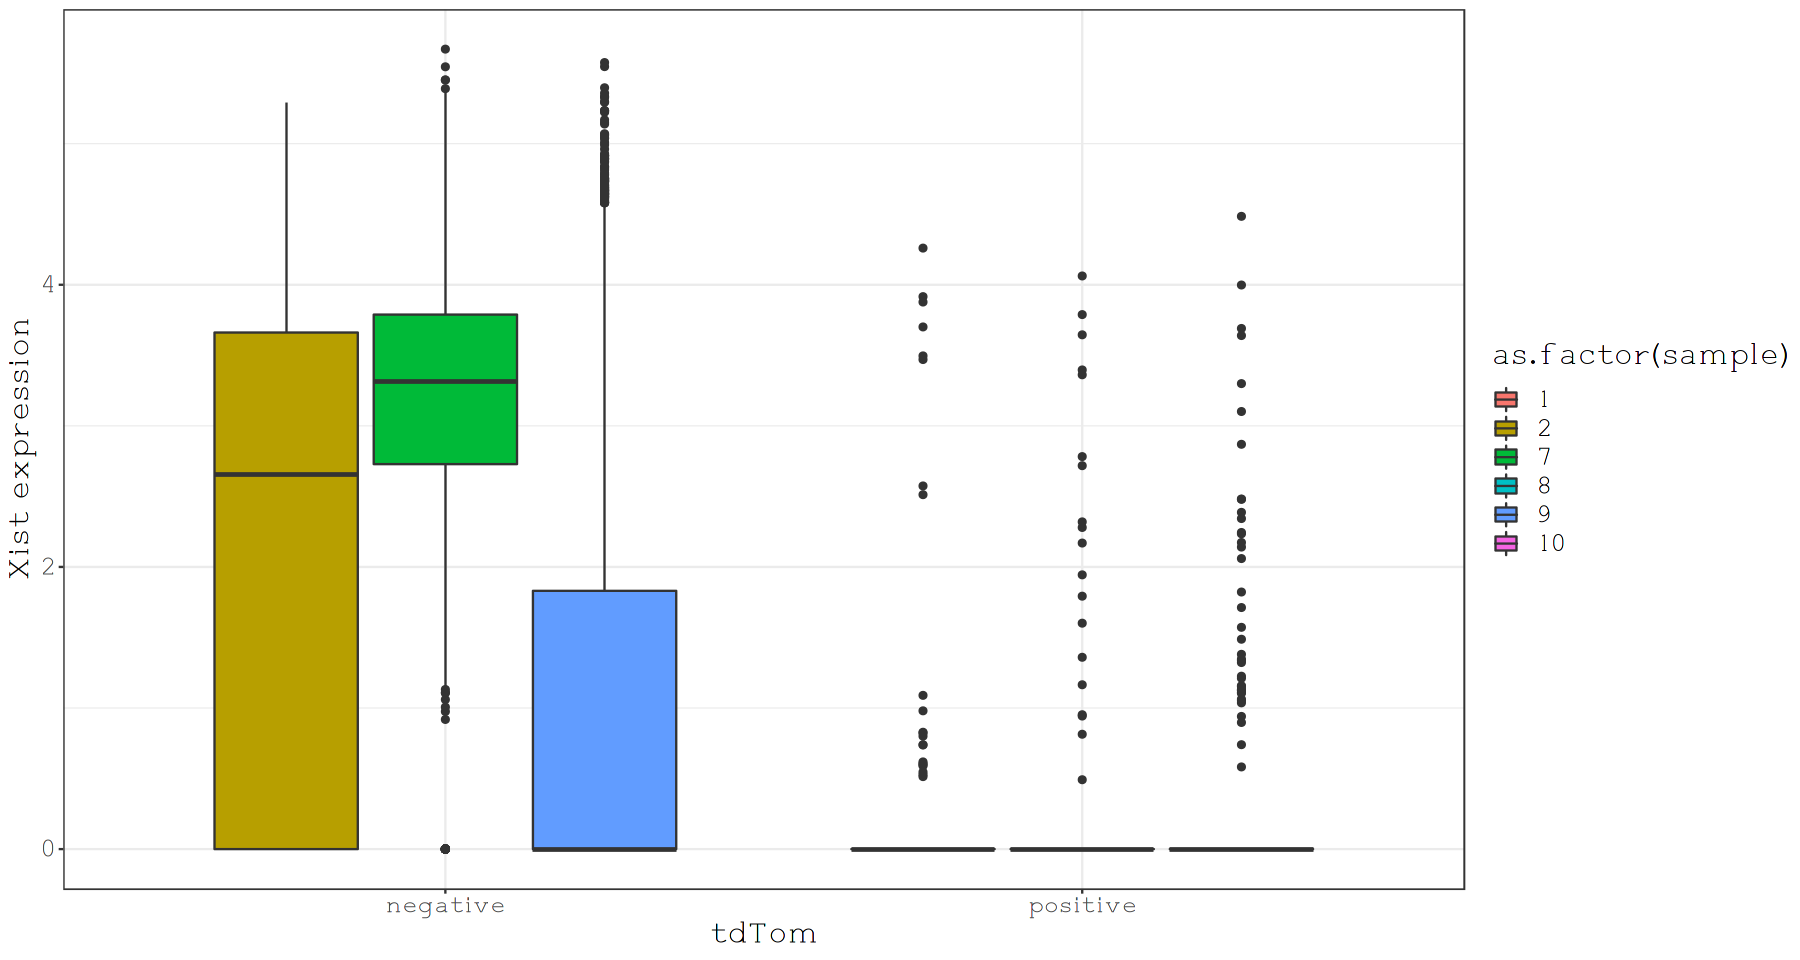

In [88]:
ggplot(meta, aes(tdTom, as.vector(logcounts(sce['Xist',])), fill=as.factor(sample))) +
    geom_boxplot(data = meta, aes(tdTom, as.vector(logcounts(sce['Xist',])))) + 
    ylab('Xist expression') + 
    theme_bw() + theme(text = element_text(size=20))

In [6]:
sce$group = meta$tdTom
sce_deg = sce
opts$groups = c('negative', 'positive')
sce_deg$group = factor(sce_deg$group, levels = opts$groups)
print(opts$groups[1])

cdr.dt <- data.table(
  rownames(sce_deg),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

out <- doDiffExpr(sce_deg, opts$groups) %>%
  # Add sample statistics
  .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
  .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
  # Add gene statistics
#  merge(cdr.dt, all.y=T, by="gene") %>%
  # Calculate statistical significance
  .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
  .[is.na(sig),sig:=FALSE] %>% 
  setorder(-sig, padj_fdr, na.last=T)

# Parse columns
out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


[1] "negative"


In [ ]:
head(out,3)

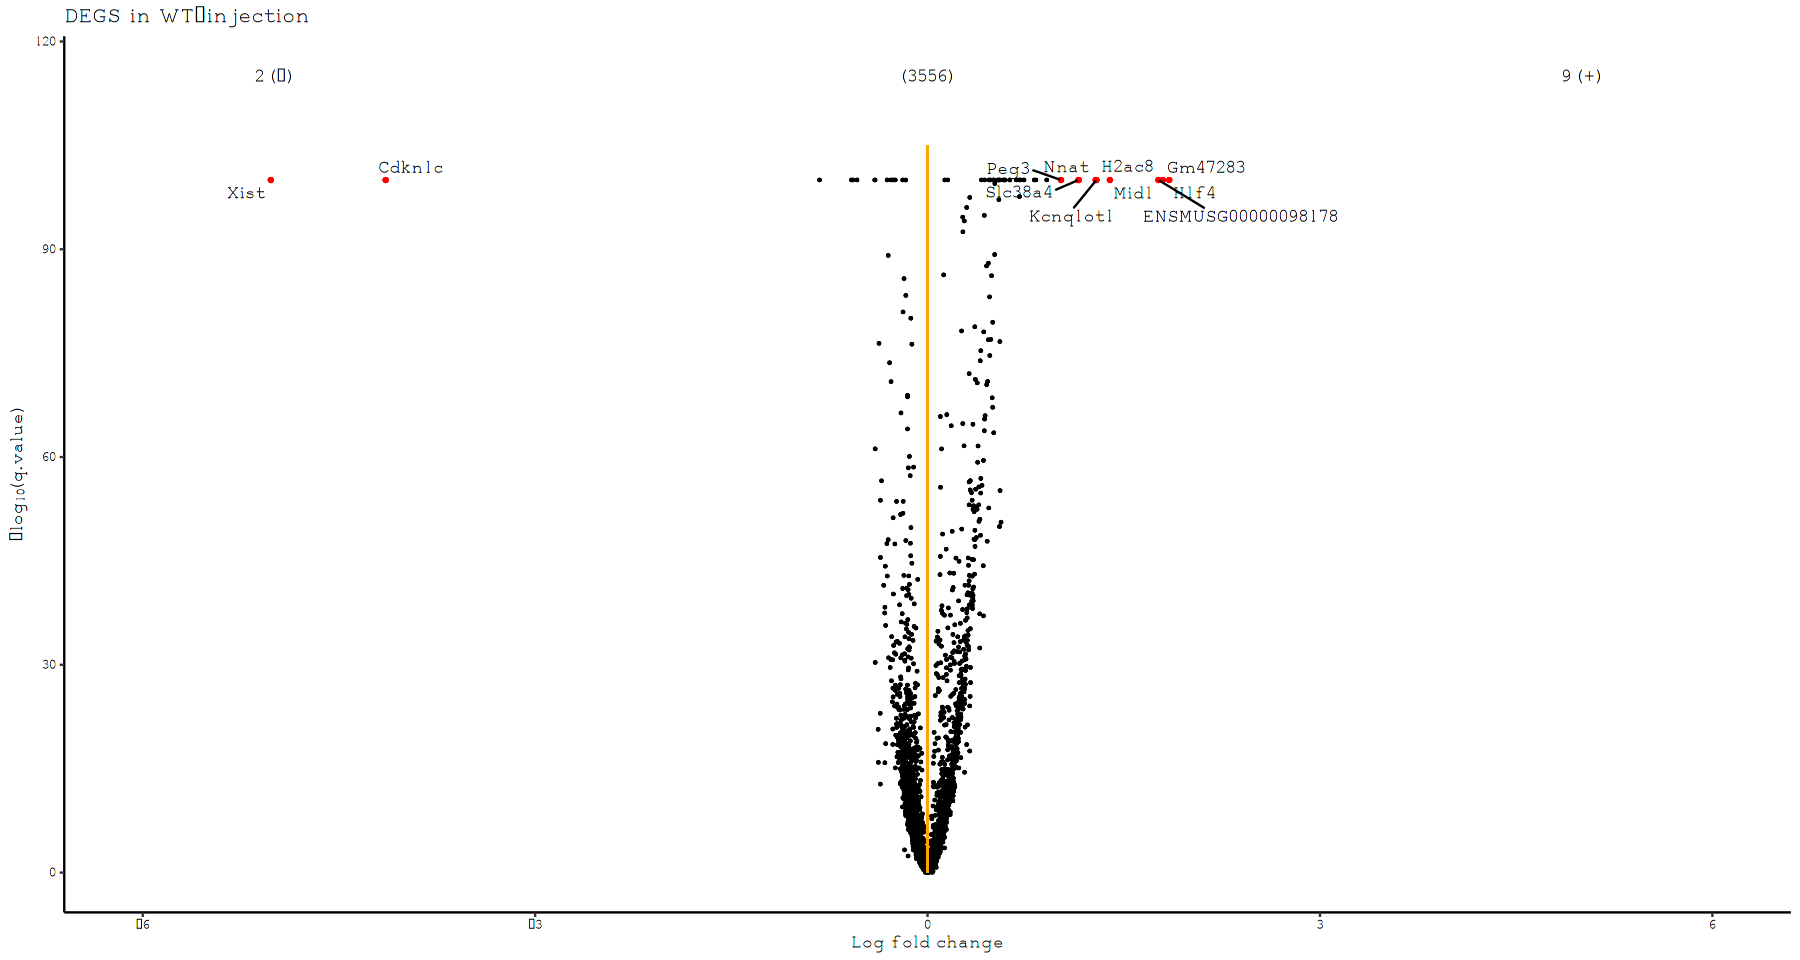

In [7]:
gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')

In [10]:
pdf(sprintf('%sedgeR_DEGs_E85_across_celltypes_WT.pdf', in_folder))
    gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')
dev.off()


png 
  2

In [11]:
write.csv(out, paste0(in_folder, 'edgeR_DEGs_E85_across_celltypes_WT.csv'), row.names=FALSE)

In [60]:
load_data()

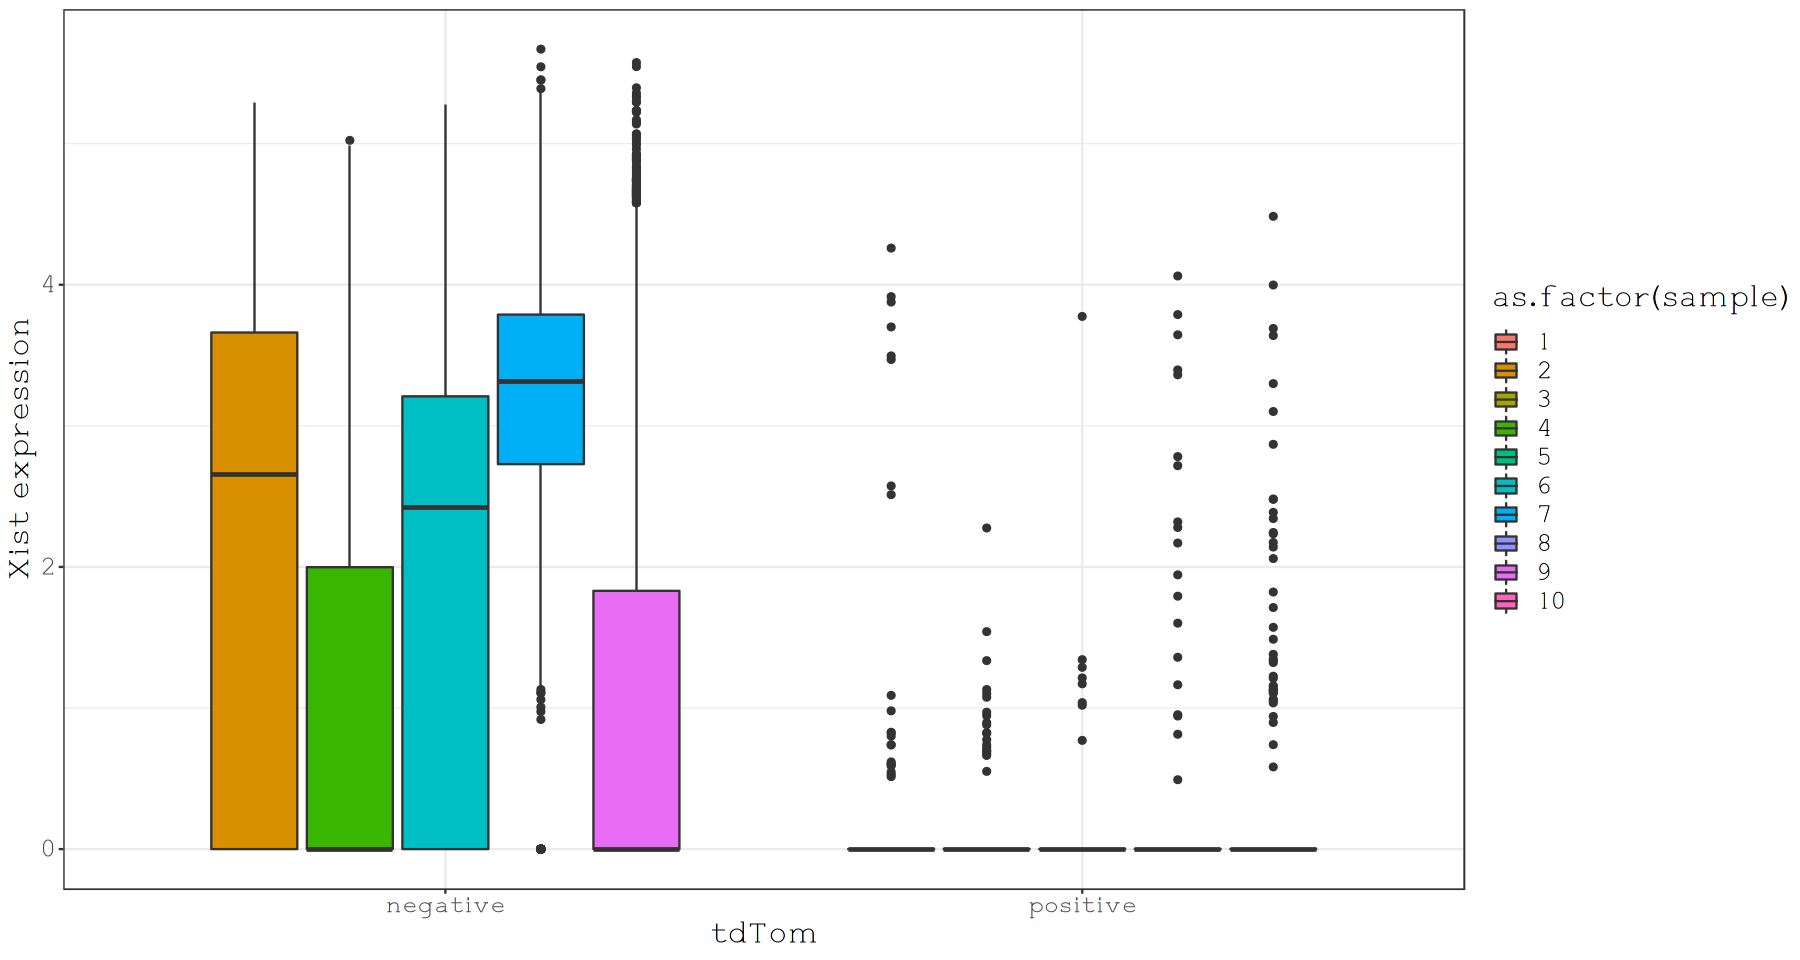

In [74]:
ggplot(meta, aes(tdTom, as.vector(logcounts(sce['Xist',])), fill=as.factor(sample))) +
    geom_boxplot(data = meta, aes(tdTom, as.vector(logcounts(sce['Xist',])))) + 
    ylab('Xist expression') + 
    theme_bw() + theme(text = element_text(size=20))

In [13]:
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

sce$group = meta$tdTom
sce_deg = sce
opts$groups = c('negative', 'positive')
sce_deg$group = factor(sce_deg$group, levels = opts$groups)
print(opts$groups[1])

cdr.dt <- data.table(
  rownames(sce_deg),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

out <- doDiffExpr(sce_deg, opts$groups) %>%
  # Add sample statistics
  .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
  .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
  # Add gene statistics
#  merge(cdr.dt, all.y=T, by="gene") %>%
  # Calculate statistical significance
  .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
  .[is.na(sig),sig:=FALSE] %>% 
  setorder(-sig, padj_fdr, na.last=T)

# Parse columns
out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


[1] "negative"


In [36]:
head(out,3)

,gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>
1,Cdkn1c,-4.274,0,0,Inf,14949,11993,negative,positive,TRUE
2,Phlda2,-3.540,0,0,Inf,14949,11993,negative,positive,TRUE
3,Gsto1,-1.800,0,0,Inf,14949,11993,negative,positive,TRUE


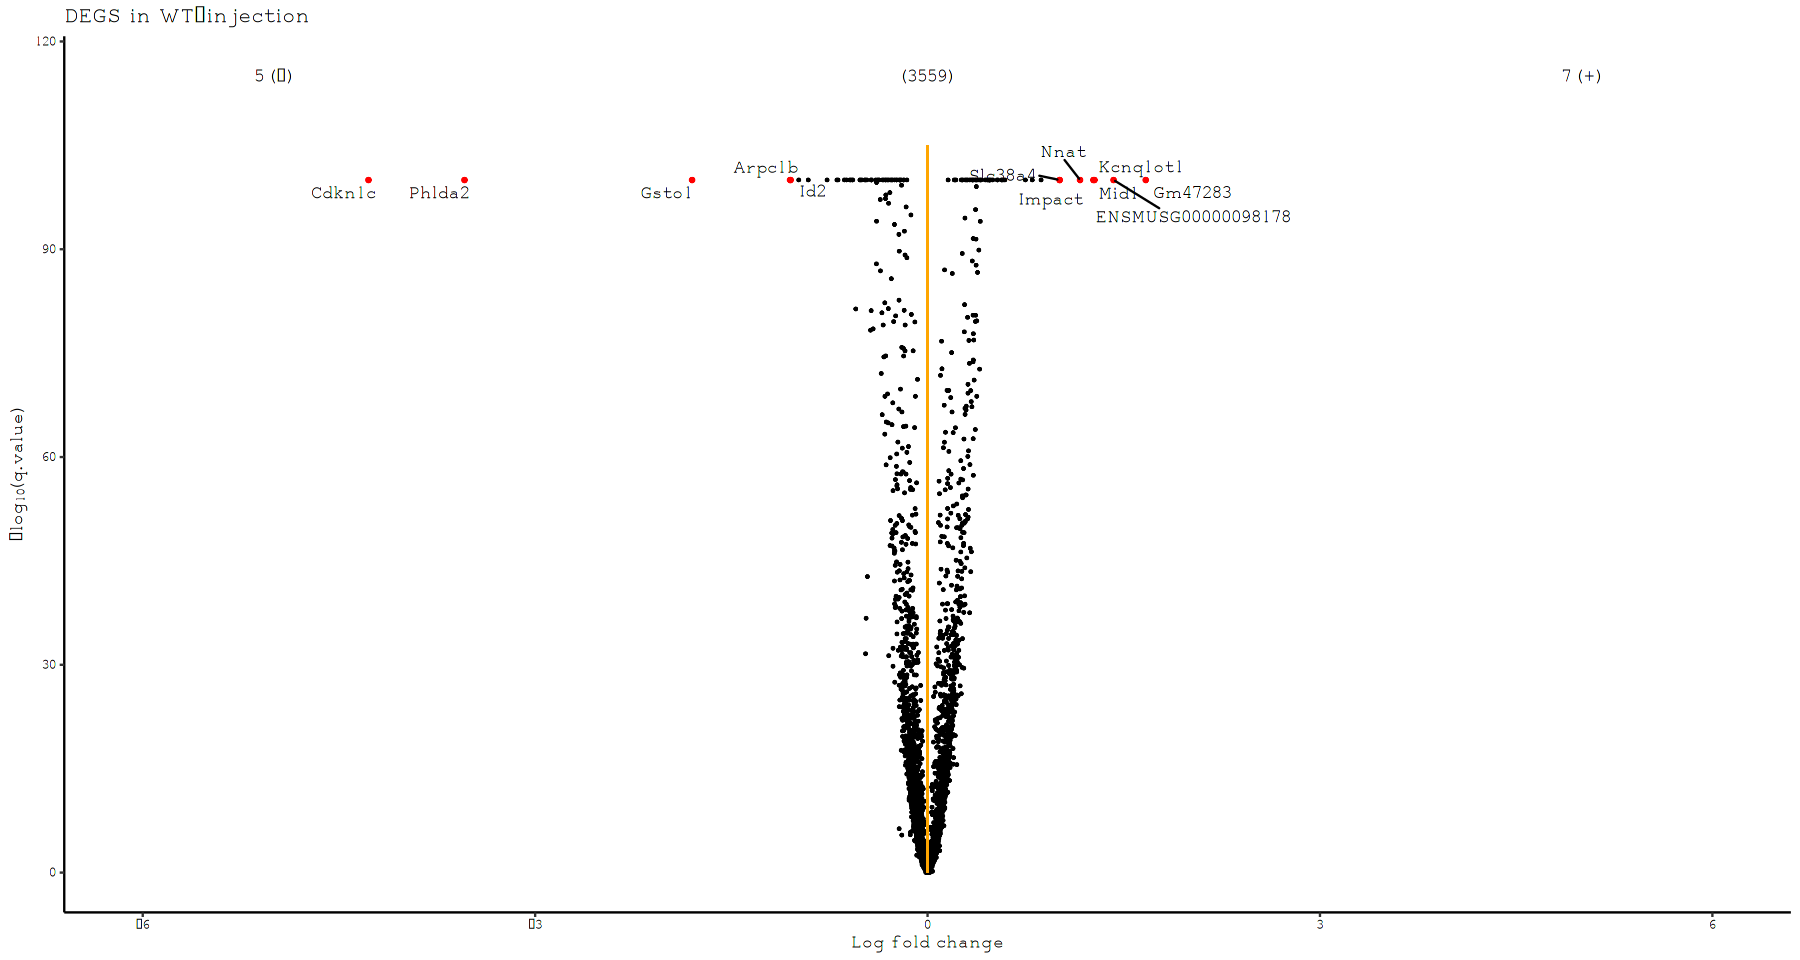

In [14]:
gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')

In [15]:
pdf(sprintf('%sedgeR_DEGs_E75_E85_across_celltypes_WT.pdf', in_folder))
    gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')
dev.off()


png 
  2

In [16]:
write.csv(out, paste0(in_folder, 'edgeR_DEGs_E75_E85_across_celltypes_WT.csv'), row.names=FALSE)

In [54]:
load_data()

In [75]:
sce = sce[, meta$sample %in% c(1,2)]
meta = meta[meta$sample %in% c(1,2),]

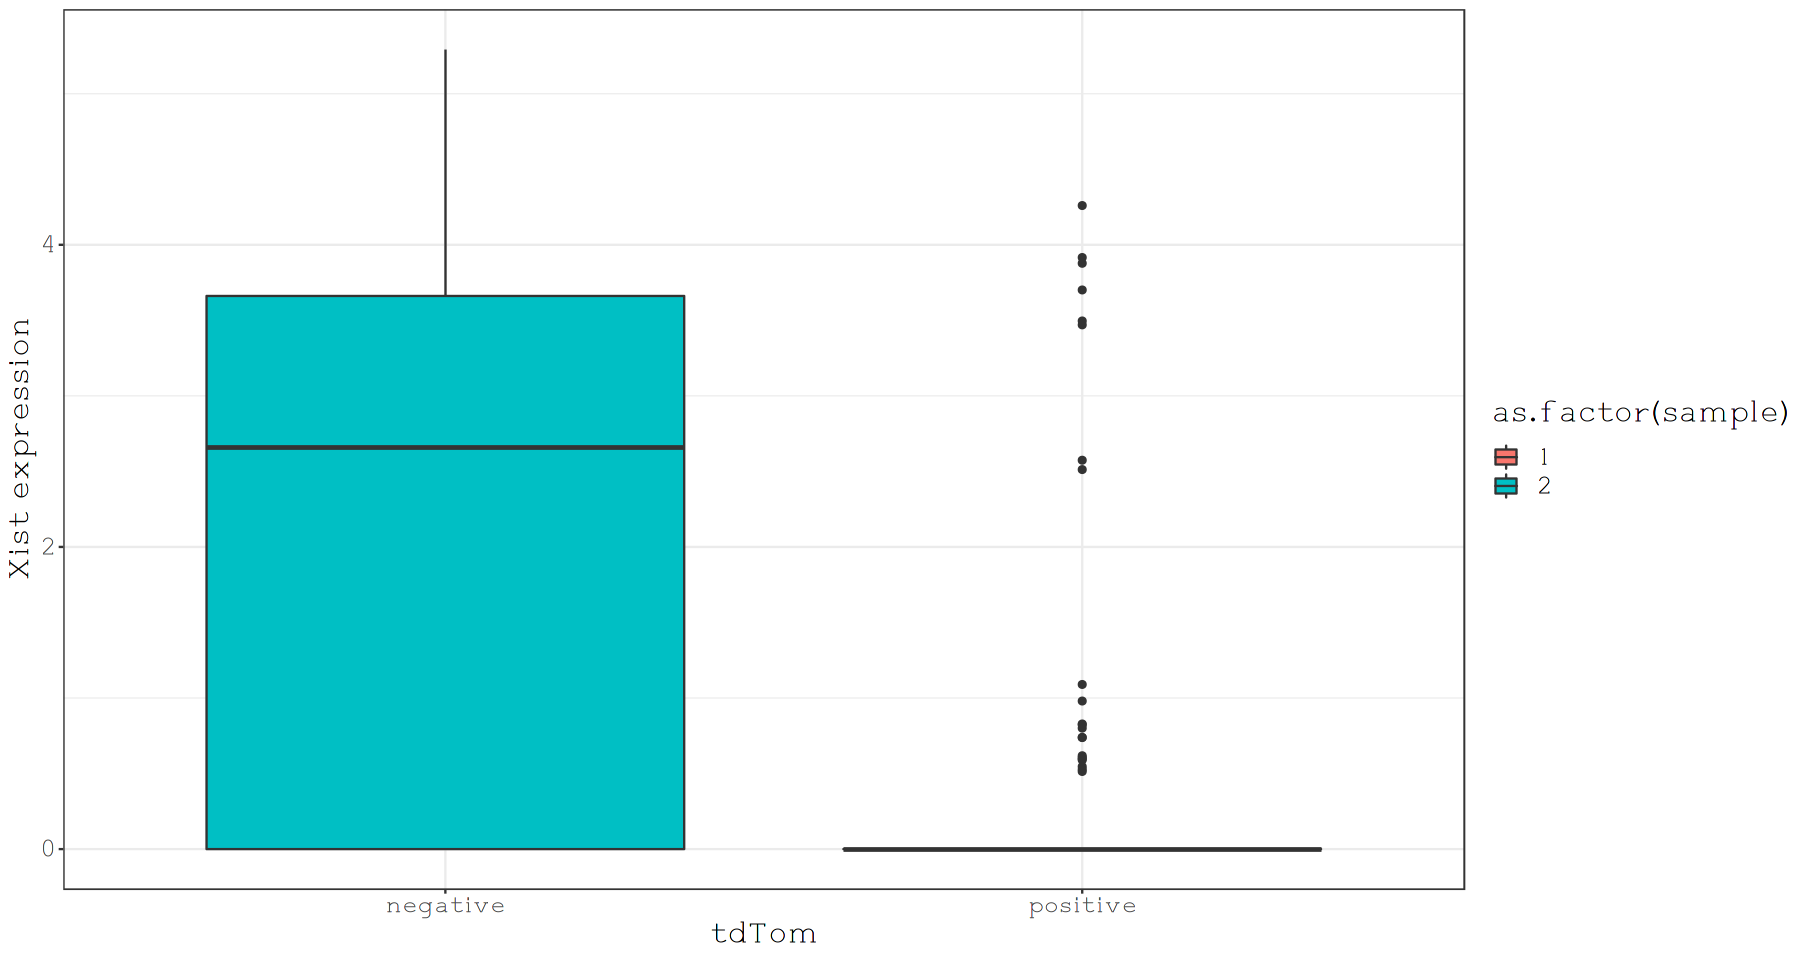

In [76]:
ggplot(meta, aes(tdTom, as.vector(logcounts(sce['Xist',])), fill=as.factor(sample))) +
    geom_boxplot(data = meta, aes(tdTom, as.vector(logcounts(sce['Xist',])))) + 
    ylab('Xist expression') + 
    theme_bw() + theme(text = element_text(size=20))

In [19]:
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

sce$group = meta$tdTom
sce_deg = sce
opts$groups = c('negative', 'positive')
sce_deg$group = factor(sce_deg$group, levels = opts$groups)
print(opts$groups[1])

cdr.dt <- data.table(
  rownames(sce_deg),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

out <- doDiffExpr(sce_deg, opts$groups) %>%
  # Add sample statistics
  .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
  .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
  # Add gene statistics
#  merge(cdr.dt, all.y=T, by="gene") %>%
  # Calculate statistical significance
  .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
  .[is.na(sig),sig:=FALSE] %>% 
  setorder(-sig, padj_fdr, na.last=T)

# Parse columns
out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


[1] "negative"


In [39]:
head(out,3)

,gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>
1,Xist,-5.851,0,0,Inf,963,2254,negative,positive,TRUE
2,Cdkn1c,-4.273,0,0,Inf,963,2254,negative,positive,TRUE
3,H1f4,3.502,0,0,Inf,963,2254,negative,positive,TRUE


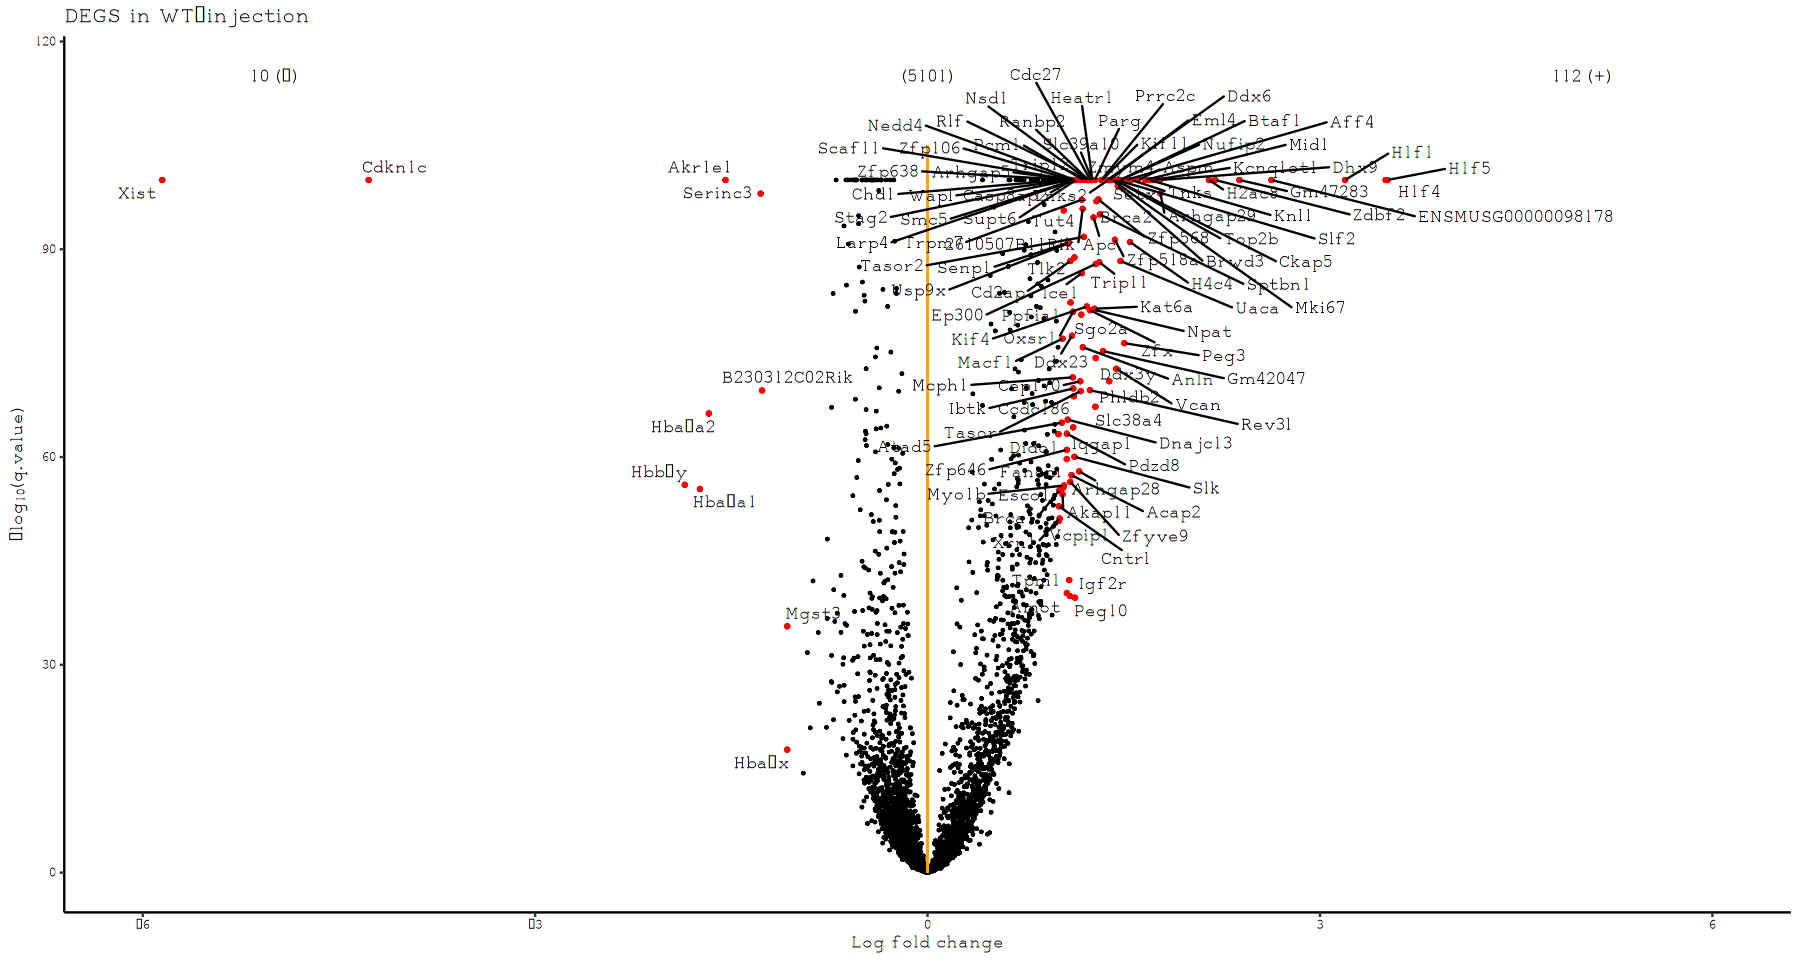

In [20]:
gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')

In [21]:
pdf(sprintf('%sedgeR_DEGs_E85_old_across_celltypes_WT.pdf', in_folder))
    gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')
dev.off()


png 
  2

In [22]:
write.csv(out, paste0(in_folder, 'edgeR_DEGs_E85_old_across_celltypes_WT.csv'), row.names=FALSE)

In [79]:
load_data()

In [80]:
sce = sce[, meta$sample %in% c(7,8,9,10)]
meta = meta[meta$sample %in% c(7,8,9,10),]

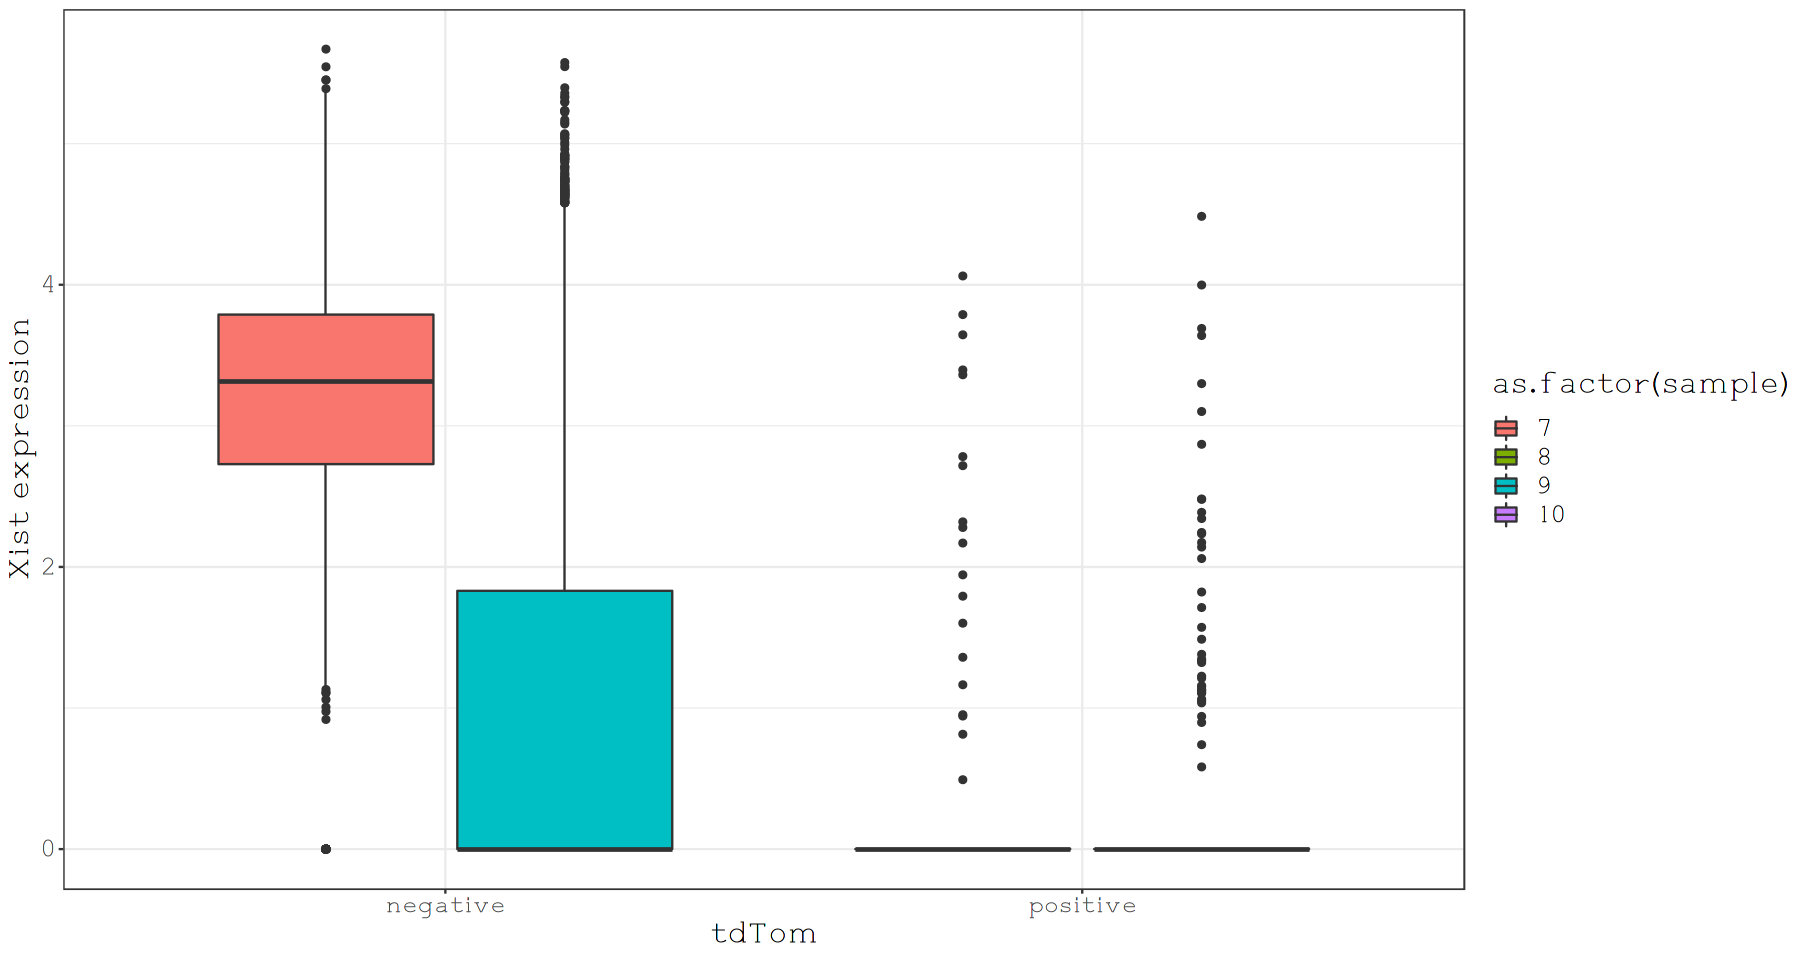

In [81]:
ggplot(meta, aes(tdTom, as.vector(logcounts(sce['Xist',])), fill=as.factor(sample))) +
    geom_boxplot(data = meta, aes(tdTom, as.vector(logcounts(sce['Xist',])))) + 
    ylab('Xist expression') + 
    theme_bw() + theme(text = element_text(size=20))

In [25]:
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

sce$group = meta$tdTom
sce_deg = sce
opts$groups = c('negative', 'positive')
sce_deg$group = factor(sce_deg$group, levels = opts$groups)
print(opts$groups[1])

cdr.dt <- data.table(
  rownames(sce_deg),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

out <- doDiffExpr(sce_deg, opts$groups) %>%
  # Add sample statistics
  .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
  .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
  # Add gene statistics
#  merge(cdr.dt, all.y=T, by="gene") %>%
  # Calculate statistical significance
  .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
  .[is.na(sig),sig:=FALSE] %>% 
  setorder(-sig, padj_fdr, na.last=T)

# Parse columns
out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


[1] "negative"


In [37]:
head(out,3)

,gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>
1,Gm47283,1.728,0,0,Inf,9577,4565,negative,positive,TRUE
2,Nnat,1.338,0,0,Inf,9577,4565,negative,positive,TRUE
3,Mid1,1.305,0,0,Inf,9577,4565,negative,positive,TRUE


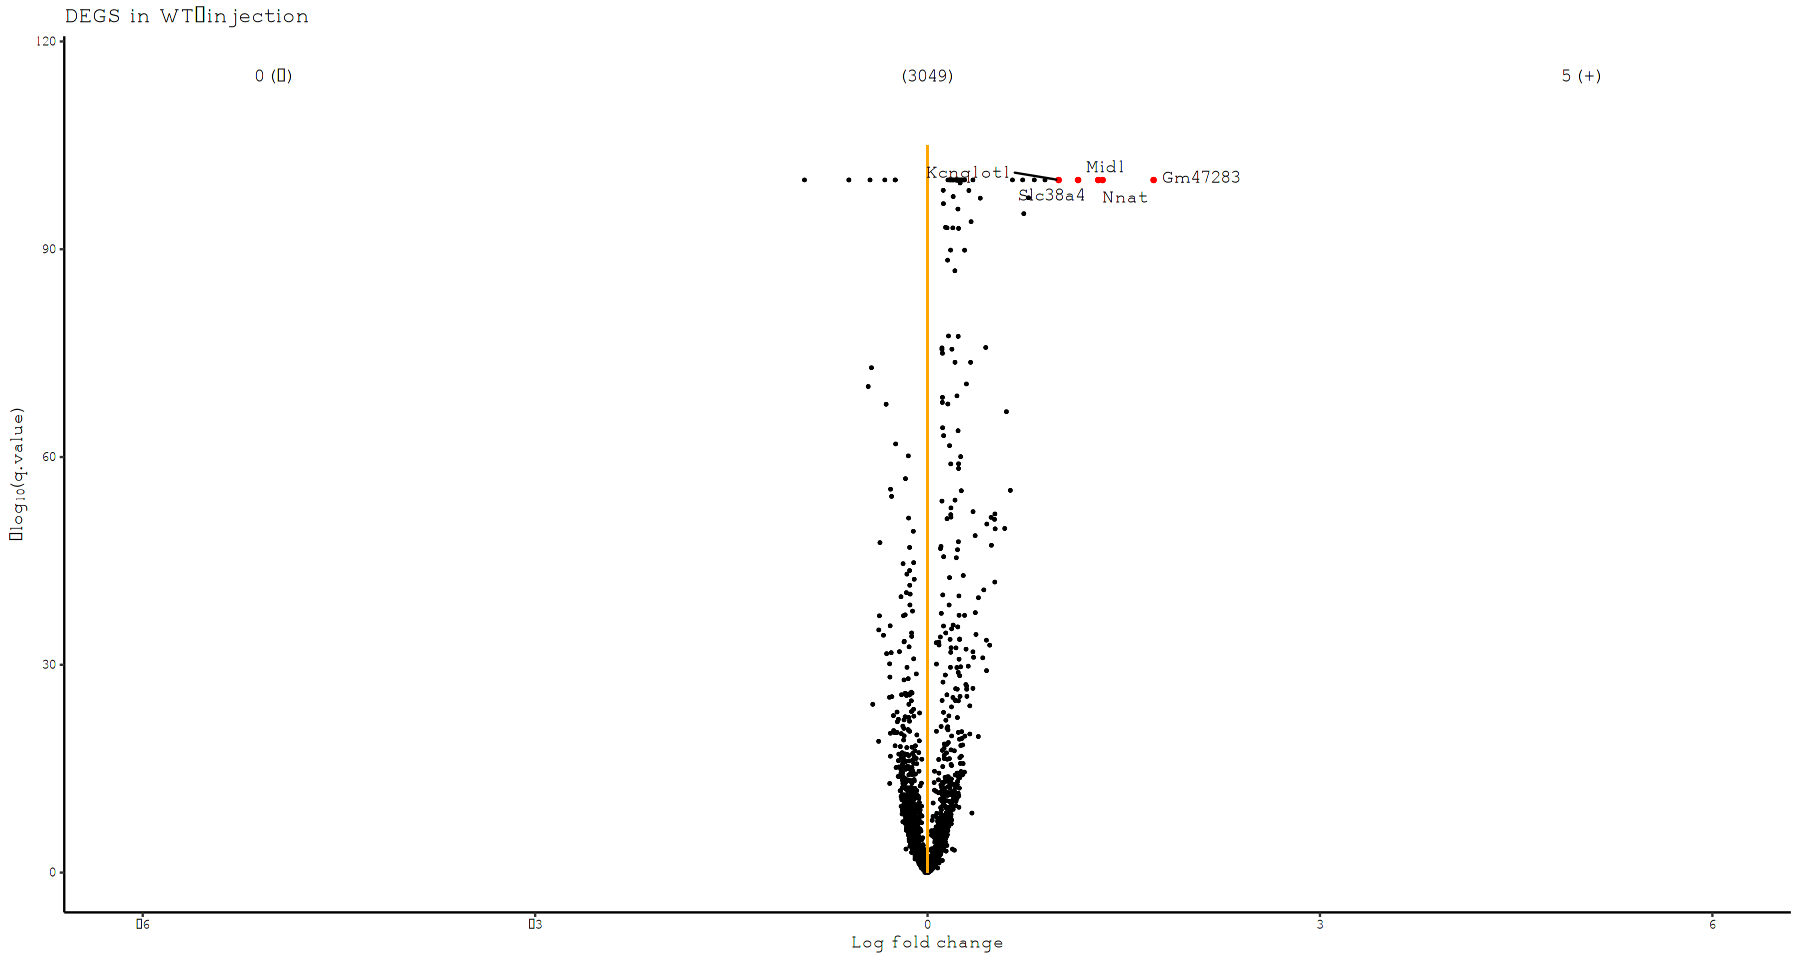

In [26]:
gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')

In [27]:
pdf(sprintf('%sedgeR_DEGs_E85_new_across_celltypes_WT.pdf', in_folder))
    gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')
dev.off()


png 
  2

In [28]:
write.csv(out, paste0(in_folder, 'edgeR_DEGs_E85_new_across_celltypes_WT.csv'), row.names=FALSE)

In [83]:
load_data()

In [84]:
sce = sce[, meta$stage=='E7.5']
meta = meta[meta$stage=='E7.5',]

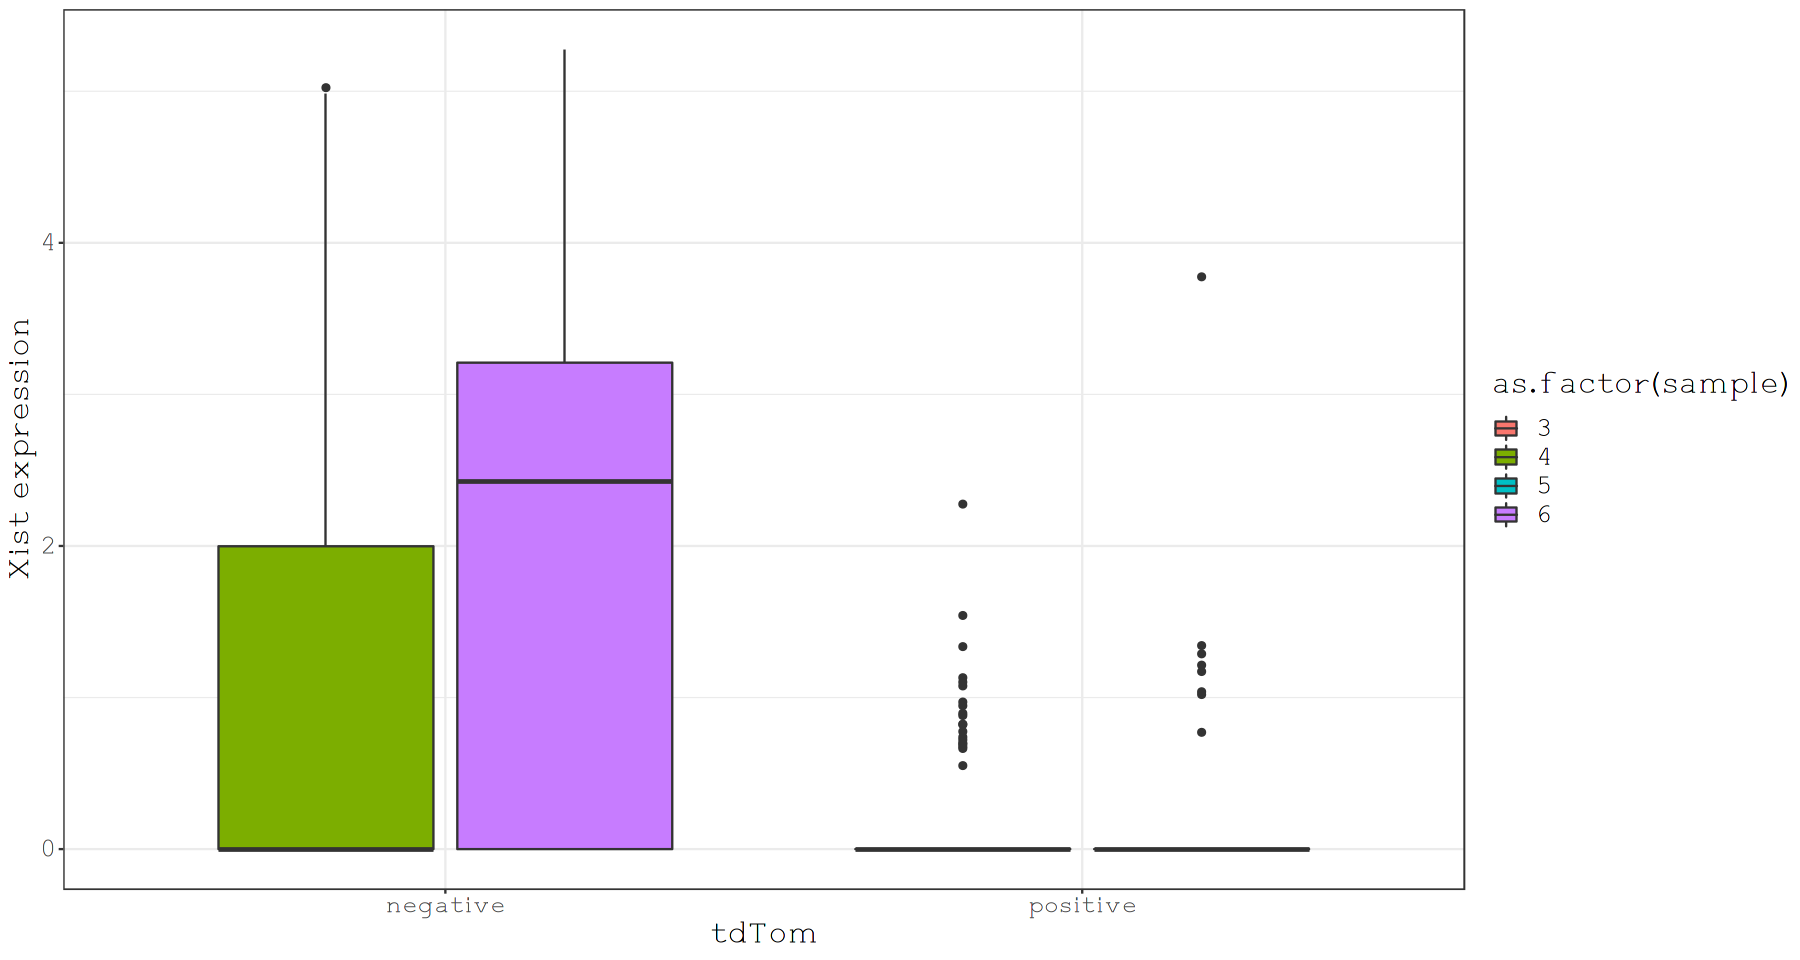

In [85]:
ggplot(meta, aes(tdTom, as.vector(logcounts(sce['Xist',])), fill=as.factor(sample))) +
    geom_boxplot(data = meta, aes(tdTom, as.vector(logcounts(sce['Xist',])))) + 
    ylab('Xist expression') + 
    theme_bw() + theme(text = element_text(size=20))

In [31]:
opts$min.logFC <- 1
opts$threshold_fdr = 0.01

sce$group = meta$tdTom
sce_deg = sce
opts$groups = c('negative', 'positive')
sce_deg$group = factor(sce_deg$group, levels = opts$groups)
print(opts$groups[1])

cdr.dt <- data.table(
  rownames(sce_deg),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[1]])>0) %>% round(2),
  rowMeans(logcounts(sce_deg[,sce_deg$group==opts$groups[2]])>0) %>% round(2)
) %>% setnames(c("gene",sprintf("detection_rate_%s",opts$groups[1]),sprintf("detection_rate_%s",opts$groups[2])))

out <- doDiffExpr(sce_deg, opts$groups) %>%
  # Add sample statistics
  .[,c("groupA_N","groupB_N"):=list(table(sce_deg$group)[1],table(sce_deg$group)[2])]%>% 
  .[,c("groupA","groupB"):=list(opts$groups[1],opts$groups[2])]%>%  
  # Add gene statistics
#  merge(cdr.dt, all.y=T, by="gene") %>%
  # Calculate statistical significance
  .[, sig := (padj_fdr<=opts$threshold_fdr & abs(logFC)>=opts$min.logFC)] %>%
  .[is.na(sig),sig:=FALSE] %>% 
  setorder(-sig, padj_fdr, na.last=T)

# Parse columns
out[,c("p.value","padj_fdr","logFC","log_padj_fdr"):=list(signif(p.value,digits=3), signif(padj_fdr,digits=3), round(logFC,3),round(log_padj_fdr,3))]


[1] "negative"


In [38]:
head(out,3)

,gene,logFC,p.value,padj_fdr,log_padj_fdr,groupA_N,groupB_N,groupA,groupB,sig
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<chr>,<chr>,<lgl>
1,Rhox5,-6.009,0,0,Inf,4409,5174,negative,positive,TRUE
2,Cdkn1c,-4.694,0,0,Inf,4409,5174,negative,positive,TRUE
3,Phlda2,-4.148,0,0,Inf,4409,5174,negative,positive,TRUE


Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”


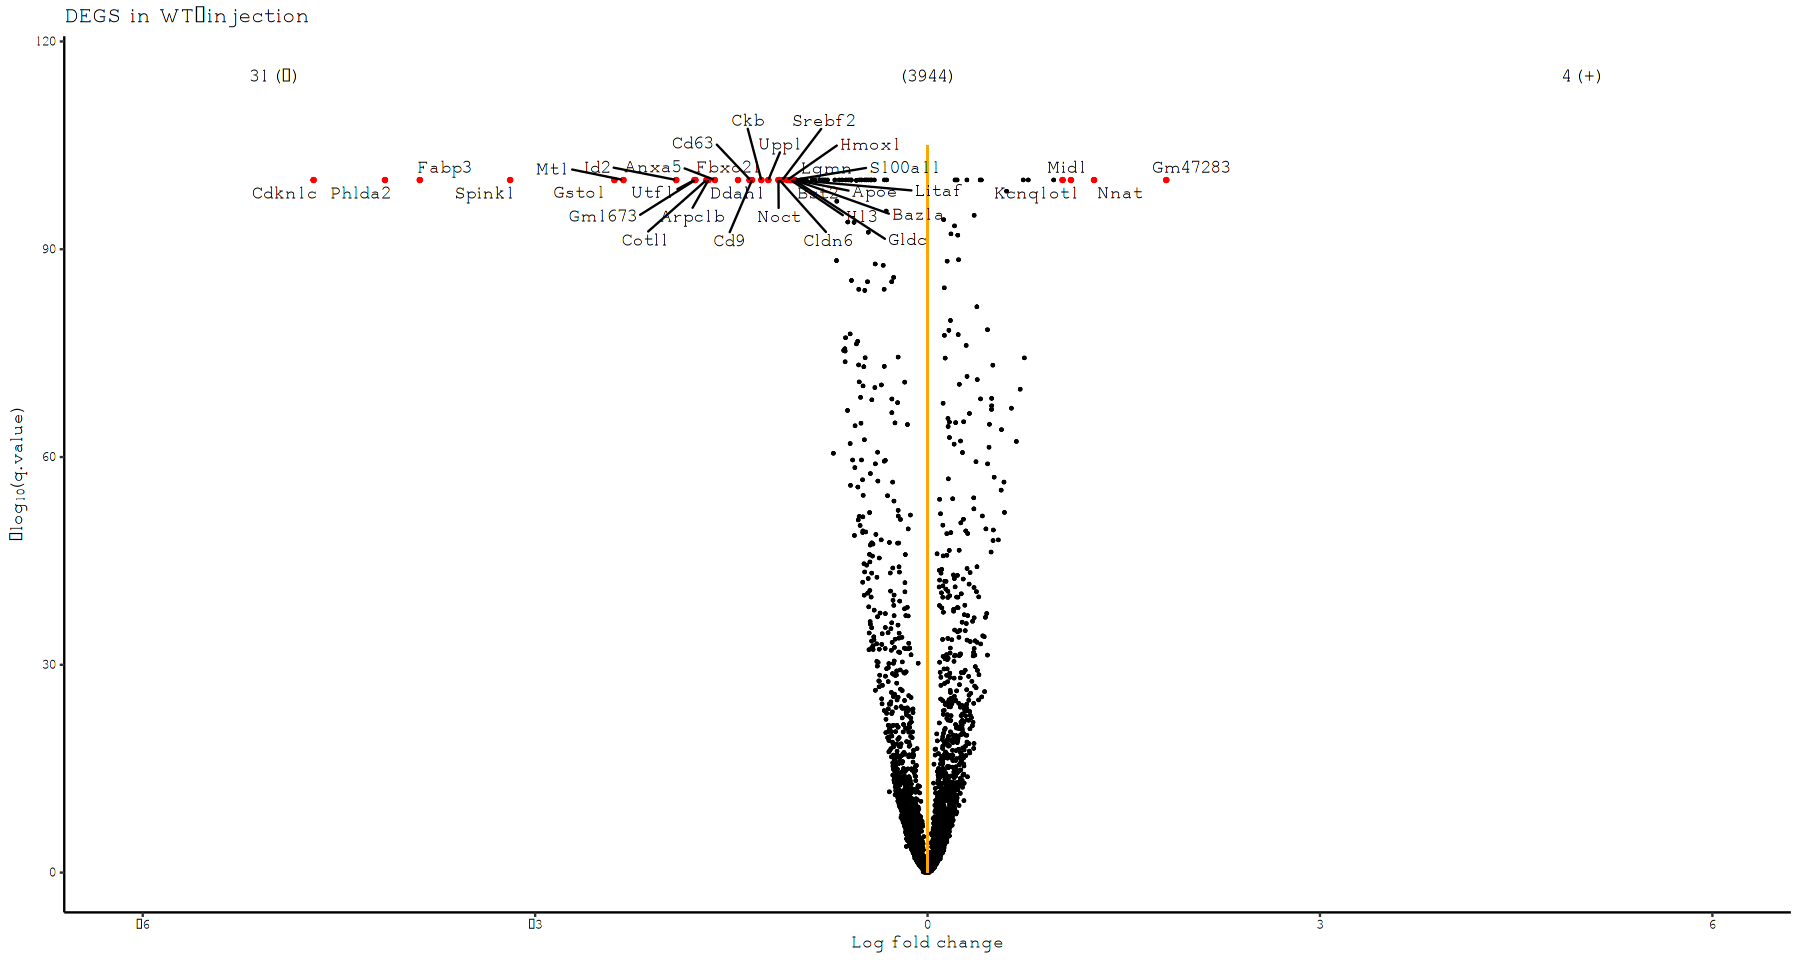

In [32]:
gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')

In [33]:
pdf(sprintf('%sedgeR_DEGs_E75_old_across_celltypes_WT.pdf', in_folder))
    gg_volcano_plot(out, 200) + ggtitle('DEGS in WT-injection')
dev.off()


Warning message:
“Removed 1 rows containing missing values (geom_point).”
Warning message:
“Removed 1 rows containing missing values (geom_text_repel).”


png 
  2

In [34]:
write.csv(out, paste0(in_folder, 'edgeR_DEGs_E75_old_across_celltypes_WT.csv'), row.names=FALSE)